In [1]:
 # gender age 공분산 통해서 회귀분석 돌린다..?
 # 두개의 영향을 보고싶지 않을 때

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

In [3]:
data = pd.read_csv("data/healthcare-dataset-stroke-data.csv") # 데이터 불러오기
data.head() # 데이터 위에서 5개만 보기

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
column_unique = ['gender', 'hypertension', 'heart_disease',  # unique 값을 보고싶은 열만 변수에 저장
                 'ever_married','work_type', 'Residence_type', 
                 'smoking_status', 'stroke']

In [5]:
for i in column_unique: # 각 행별로 어떤 값들이 있는지 
    a = data[i].unique()
    print(a)

['Male' 'Female' 'Other']
[0 1]
[1 0]
['Yes' 'No']
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
['Urban' 'Rural']
['formerly smoked' 'never smoked' 'smokes' 'Unknown']
[1 0]


In [6]:
data.info() # 결측값 확인 / age 실수인것 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


# 전처리

## 이상치 
- gender

In [7]:
data["gender"].value_counts() #  한 개밖에 없어서 제거 결정

Female    2994
Male      2115
Other        1
Name: gender, dtype: int64

In [8]:
data.loc[data["gender"] == "Other"].index

Int64Index([3116], dtype='int64')

In [9]:
data = data.drop(data.loc[data["gender"] == "Other"].index, axis=0).copy() # Other 행 삭제

In [10]:
data["gender"].value_counts() # 지워졌나 확인

Female    2994
Male      2115
Name: gender, dtype: int64

## 결측값
- 흡연 컬럼의 unkown
- bmi 결측값

In [11]:
data["smoking_status"].value_counts()

never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: smoking_status, dtype: int64

In [12]:
1544/(1892+884+789) * 100 # 결측값 비율 43%

43.30995792426368

In [13]:
data = data.drop(data.loc[data["smoking_status"]=="Unknown"].index, axis = 0).copy() # Unkown이 있는 행 모두 삭제

In [14]:
data["smoking_status"].value_counts()

never smoked       1892
formerly smoked     884
smokes              789
Name: smoking_status, dtype: int64

In [15]:
data = data.loc[~data["bmi"].isna()] # bmi가 결측값이 아닌 행들만 가져옴

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3425 entries, 0 to 5108
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 3425 non-null   int64  
 1   gender             3425 non-null   object 
 2   age                3425 non-null   float64
 3   hypertension       3425 non-null   int64  
 4   heart_disease      3425 non-null   int64  
 5   ever_married       3425 non-null   object 
 6   work_type          3425 non-null   object 
 7   Residence_type     3425 non-null   object 
 8   avg_glucose_level  3425 non-null   float64
 9   bmi                3425 non-null   float64
 10  smoking_status     3425 non-null   object 
 11  stroke             3425 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 347.9+ KB


## 자료형 변경
- age 실수 -> 정수

In [17]:
data = data.astype({"age":int})

In [18]:
data["age"].dtype

dtype('int32')

## 이진화 / 더미변수
- gender
- ever_married
- Residence_type
- smoking_status
- work_type

In [19]:
data['gender'] = data['gender'].apply(lambda x: 1 if x=='Male' else 0) # 이진화 
data['ever_married'] = data['ever_married'].apply(lambda x: 1 if x=='Yes' else 0)
data['Residence_type'] = data['Residence_type'].apply(lambda x: 1 if x=='Urban' else 0)

In [20]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67,0,1,1,Private,1,228.69,36.6,formerly smoked,1
2,31112,1,80,0,1,1,Private,0,105.92,32.5,never smoked,1
3,60182,0,49,0,0,1,Private,1,171.23,34.4,smokes,1
4,1665,0,79,1,0,1,Self-employed,0,174.12,24.0,never smoked,1
5,56669,1,81,0,0,1,Private,1,186.21,29.0,formerly smoked,1


In [21]:
# 더미변수 만들기
data = pd.get_dummies(data, columns = ['work_type','smoking_status']).copy()


In [22]:
data.columns = data.columns.str.replace('work_type_', '') # 더미변수로 바꿀 때 고정적으로 붙는 접두어 삭제
data.columns = data.columns.str.replace('smoking_status_', '')


In [23]:
# id 열은 필요 없으니까 삭제
data = data.drop(columns="id",axis=1)

In [24]:
# stroke 맨뒤로 보내줌
# col2 열의 위치를 가져옴
col2_idx = data.columns.get_loc('stroke')

# 열 순서를 변경한 새로운 데이터프레임 생성
new_order = list(range(len(data.columns)))
new_order.pop(col2_idx)
new_order.append(col2_idx)
data = data.reindex(columns=data.columns[new_order])

In [25]:
data.head(3)

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,Govt_job,Never_worked,Private,Self-employed,children,formerly smoked,never smoked,smokes,stroke
0,1,67,0,1,1,1,228.69,36.6,0,0,1,0,0,1,0,0,1
2,1,80,0,1,1,0,105.92,32.5,0,0,1,0,0,0,1,0,1
3,0,49,0,0,1,1,171.23,34.4,0,0,1,0,0,0,0,1,1


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3425 entries, 0 to 5108
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             3425 non-null   int64  
 1   age                3425 non-null   int32  
 2   hypertension       3425 non-null   int64  
 3   heart_disease      3425 non-null   int64  
 4   ever_married       3425 non-null   int64  
 5   Residence_type     3425 non-null   int64  
 6   avg_glucose_level  3425 non-null   float64
 7   bmi                3425 non-null   float64
 8   Govt_job           3425 non-null   uint8  
 9   Never_worked       3425 non-null   uint8  
 10  Private            3425 non-null   uint8  
 11  Self-employed      3425 non-null   uint8  
 12  children           3425 non-null   uint8  
 13  formerly smoked    3425 non-null   uint8  
 14  never smoked       3425 non-null   uint8  
 15  smokes             3425 non-null   uint8  
 16  stroke             3425 

## 표준화/정규화

- 정규화 : 데이터 셋 최솟값이 0이 되고, 데이터셋의 최대값 1 분포에 영향x

In [27]:
from sklearn.preprocessing import MinMaxScaler
# 정규화
scaler = MinMaxScaler()
data_normalized = data.copy()
data_normalized[["age","avg_glucose_level","bmi"]] = scaler.fit_transform(data_normalized[["age","avg_glucose_level","bmi"]])

In [28]:
data_normalized

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,Govt_job,Never_worked,Private,Self-employed,children,formerly smoked,never smoked,smokes,stroke
0,1,0.791667,0,1,1,1,0.801265,0.311801,0,0,1,0,0,1,0,0,1
2,1,0.972222,0,1,1,0,0.234512,0.260870,0,0,1,0,0,0,1,0,1
3,0,0.541667,0,0,1,1,0.536008,0.284472,0,0,1,0,0,0,0,1,1
4,0,0.958333,1,0,1,0,0.549349,0.155280,0,0,0,1,0,0,1,0,1
5,1,0.986111,0,0,1,1,0.605161,0.217391,0,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5100,1,1.000000,1,0,1,0,0.077786,0.208696,0,0,0,1,0,0,1,0,0
5102,0,0.652778,0,0,1,0,0.105300,0.126708,0,0,1,0,0,0,1,0,0
5106,0,0.986111,0,0,1,1,0.323516,0.354037,0,0,0,1,0,0,1,0,0
5107,0,0.347222,0,0,1,0,0.128658,0.237267,0,0,0,1,0,0,1,0,0


# 로지스틱 회귀 모델

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import brier_score_loss

from sklearn.datasets import make_classification
from sklearn.metrics import precision_score, recall_score, roc_auc_score


In [30]:
# 설명
# gender ->  남자: 1 여자: 0
# Residence_type -> Urban: 1 Rural: 0

In [31]:
data_normalized.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'Govt_job',
       'Never_worked', 'Private', 'Self-employed', 'children',
       'formerly smoked', 'never smoked', 'smokes', 'stroke'],
      dtype='object')

In [32]:
features = data_normalized[['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'Govt_job',
       'Never_worked', 'Private', 'Self-employed', 'children',
       'formerly smoked', 'never smoked', 'smokes']]
stroke = data_normalized['stroke']

In [33]:
from sklearn.model_selection import train_test_split
train_features, test_features, train_labels, test_labels = train_test_split(features, stroke)

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

In [35]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(train_features, train_labels)

LogisticRegression()

In [36]:
print(model.score(train_features, train_labels))

0.9462616822429907


In [37]:
print(model.score(test_features, test_labels))

0.9498249708284714


In [38]:
print(model.coef_)

[[-0.07671751  1.36650842  0.22034861  0.12338123 -0.06258425 -0.05694427
   0.18320402  0.02152396 -0.02049833 -0.07986907  0.09959679 -0.03425487
  -0.15995736 -0.02076874 -0.06019375  0.09582427]]


혼돈 매트릭스 (Confusion Matrix)
- Accuracy = (TP+TN)/N
- Recall(sensitivity) = TP/(TP+FN)
- Specificity = TN/(FP+TN)
- precision = TP/(TP+FP)
- F-1 Score = 2 / {(1/precision)+ (1/recall)}
- Fall-out(FPR) : FP / (TN+FP)
- ROC(Receiver Operating Characteristic) curve : Recall / FPR / 커브가 왼쪽 모서리에 가까울수록 좋은 모델/y=x 그래프보다 상단에 위치해야
- AUC(Area Under Curve) :  최댓값 1이고 1에 가까울수록 좋은 모델

 - Precision(정밀도) : 양성이라고 예측한 것 대미 실제로 양성의 비율 // recall과 함께 고려되야함(예측한 수도 고려해야하기 때문에)
 - recall(재현율) : 실제 True인 data 중에서 모델이 True로 분류한 비율) // 예측한 수도 고려한 것
 - Fall-out(FPR) : False인 data 중에서 모델이 True로 분류한 비율
 - accuracy(정확도) : 전체 샘플 대비 맞게 예측한 샘플 수 비율
 - f1-score : precision과 recall의 가중 조화평균
 - macro avg : 각 클래스 별로 동일한 가중치 부여/ 불균형 고려x 
 - weighted avg :  각 클래스 속하는 표본의 개수로 가중 평균내서 계산/불균형 고려o


In [39]:
# 로지스틱 회귀분석 모델 학습
model = LogisticRegression()
model.fit(train_features, train_labels)

# 예측 결과 출력
y_pred = model.predict(test_features)
print(classification_report(test_labels ,y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       815
           1       0.00      0.00      0.00        42

    accuracy                           0.95       857
   macro avg       0.48      0.50      0.49       857
weighted avg       0.90      0.95      0.93       857



In [40]:
# 로지스틱 회귀분석 모델 학습
model = LogisticRegression(class_weight='balanced') # class_weight='balanced' 파라미터 추가(불균형 데이터 고려)
model.fit(train_features, train_labels)

# 예측 결과 출력
y_pred = model.predict(test_features)
print(classification_report(test_labels ,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.72      0.83       815
           1       0.13      0.81      0.22        42

    accuracy                           0.72       857
   macro avg       0.56      0.76      0.53       857
weighted avg       0.94      0.72      0.80       857



In [41]:
y_pred_prob = model.predict_proba(test_features)[:,1]  # 클래스 1에 속할 확률 예측값
brier_score = brier_score_loss(test_labels, y_pred_prob)  # Brier score 계산
print("Brier score: {:.4f}".format(brier_score))

Brier score: 0.1860


- 나는 1에 관한 평가를 보는게 중요할듯!! / 뇌졸중 여부를 확인하는게 중요하니까

 즉, Precision이나 Recall은 모두 실제 True인 정답을 모델이 True라고 예측한 경우에 관심이 있으나, 바라보고자 하는 관점만 다릅니다.
Precision은 모델의 입장에서, 그리고 Recall은 실제 정답(data)의 입장에서 정답을 정답이라고 맞춘 경우를 바라보고 있습니다. 다음의 경우를 생각해보겠습니다.

- precision : 0 이라고 예측한 값중에 99%가 0이었음 /  1 이라고 예측한 값중에 13%가 1이었음
- recall : 실제 0인 값들 중 69%가 0 이라고 판별됨 / 실제 1인 값들 중 88%가 1 이라고 판별됨--> 예측한게 13%만 맞았는데 어떻게 진짜 1인 것중에 88%를 판별해낸건지..?


# 불균형 데이터 처리

언더샘플링
- Tomek Links
- CNN Rule

오버샘플링
- Resampling - 소수 범주 무작위 복제
- SMOTE - 임의 데이터 생성
- Borderline SMOTE
- ADASYN
- GAN

In [42]:
pip install -U imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


## 오버샘플링

### SMOTE

#### SMOTE 후 test/train 분리

In [43]:
#x_columns = data.iloc[:,:-1].columns # 독립변수를 변수에 할당
x = data_normalized.drop("stroke",axis = 1) #독립변수
y = data_normalized["stroke"] # 종속변수

In [44]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
x_resampled_smote, y_resampled_smote = smote.fit_resample(x,y)

# 분포 변화
print("before SMOTE :\n", y.value_counts())
print("\nbefore SMOTE :\n", y_resampled_smote.value_counts())

before SMOTE :
 0    3245
1     180
Name: stroke, dtype: int64

before SMOTE :
 1    3245
0    3245
Name: stroke, dtype: int64


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_smote, y_resampled_smote, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 로지스틱 회귀분석 모델 학습
model = LogisticRegression()
model.fit(x_train, y_train)


# 예측 결과 출력
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.83      0.73      0.78      1008
           1       0.74      0.84      0.79       939

    accuracy                           0.78      1947
   macro avg       0.79      0.78      0.78      1947
weighted avg       0.79      0.78      0.78      1947



In [46]:
# F0.5 Score 값
from sklearn.metrics import precision_score, recall_score, fbeta_score

# 모델 예측값(predicted)과 실제값(actual)을 가지고 있을 때
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f_beta_score = fbeta_score(y_test, y_pred, beta=0.5)
print(f_beta_score)

0.7592128111132548


In [47]:
# Precision, Recall, AUC 평가
# 모델 예측
y_pred = model.predict(x_test)
y_pred_prob = model.predict_proba(x_test)[:, 1]

# Precision, Recall, AUC 평가
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
print(auc)

0.8558158797775411


In [48]:
# Brier score 계산
y_pred_prob = model.predict_proba(x_test)[:,1]  # 클래스 1에 속할 확률 예측값 / 뭔지 잘 모르겠음
brier_score = brier_score_loss(y_test, y_pred_prob)  
print("Brier score: {:.4f}".format(brier_score))

Brier score: 0.1520


#### test,train data 나눈 후 SMOTE

- 기존 데이터에서 먼저 test/train 데이터 나누고 나뉘어진 데이터를 smote
- smote를 하고 나누면 데이터들이 서로 독립적이라고 할 수 없음 (영향을 받은 데이터들이 있기 때문에)

In [49]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [50]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
x_resampled_smote, y_resampled_smote = smote.fit_resample(x_train,y_train)

# 분포 변화
print("before SMOTE :\n", y.value_counts())
print("\nbefore SMOTE :\n", y_resampled_smote.value_counts())

before SMOTE :
 0    3245
1     180
Name: stroke, dtype: int64

before SMOTE :
 0    2276
1    2276
Name: stroke, dtype: int64


In [51]:
# SMOTE 전후 종속변수 분포 차이 시각화
# plt.figure(figsize=(8, 5))
# plt.title('Class Distribution after SMOTE')
# plt.hist(y_resampled_smote, bins=2)
# plt.xticks([0, 1], labels=['Negative', 'Positive'])
# plt.xlabel('Class')
# plt.ylabel('Count')
# plt.show()

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_smote, y_resampled_smote, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 로지스틱 회귀분석 모델 학습
model = LogisticRegression()
model.fit(x_train, y_train)


# 예측 결과 출력
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))



              precision    recall  f1-score   support

           0       0.82      0.75      0.78       692
           1       0.76      0.82      0.79       674

    accuracy                           0.79      1366
   macro avg       0.79      0.79      0.79      1366
weighted avg       0.79      0.79      0.79      1366



In [53]:
# F0.5 Score 값
from sklearn.metrics import precision_score, recall_score, fbeta_score

# 모델 예측값(predicted)과 실제값(actual)을 가지고 있을 때
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f_beta_score = fbeta_score(y_test, y_pred, beta=0.5)
print(f_beta_score)

0.7761027359017308


In [54]:
# Precision, Recall, AUC 평가
# 모델 예측
y_pred = model.predict(x_test)
y_pred_prob = model.predict_proba(x_test)[:, 1]

# Precision, Recall, AUC 평가
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
print(auc)

0.8577061285398192


In [55]:
  # Brier score 계산
y_pred_prob = model.predict_proba(x_test)[:,1]  # 클래스 1에 속할 확률 예측값 / 뭔지 잘 모르겠음
brier_score = brier_score_loss(y_test, y_pred_prob)  
print("Brier score: {:.4f}".format(brier_score))

Brier score: 0.1503


In [105]:
from sklearn.datasets import load_iris

# 데이터 로드
iris = load_iris()
x = iris.data
y = iris.target

# 로지스틱 회귀분석 모델 훈련
clf = LogisticRegression(random_state=0).fit(x_train, y_train)
# train data를 가지고 계수 확인해야됨 / test data는 그냥 없는 데이터라고 생각

# 각 독립 변수의 계수 값 확인
print(clf.coef_)

[[-0.4912822   6.43202499 -0.09467611 -0.72078995 -0.13947462 -0.3051396
   1.6893206   0.99218526 -2.72252475 -0.47607805 -1.90740512 -2.30389231
  -1.03947299 -2.03274703 -1.94904127 -1.20175477]]


# 가장 영향을 주는 변수 찾기 

In [63]:
a = x_train.columns

In [74]:
b = clf.coef_
# 1차원으로 변환
b_1d = b.ravel()

# 1차원 array 출력
print(b_1d)

[-0.4912822   6.43202499 -0.09467611 -0.72078995 -0.13947462 -0.3051396
  1.6893206   0.99218526 -2.72252475 -0.47607805 -1.90740512 -2.30389231
 -1.03947299 -2.03274703 -1.94904127 -1.20175477]


In [79]:
df = {"독립변수":a,"계수":b_1d}

df = pd.DataFrame(df)
df

,독립변수,계수
0,gender,-0.491282
1,age,6.432025
2,hypertension,-0.094676
3,heart_disease,-0.720790
4,ever_married,-0.139475
5,Residence_type,-0.305140
6,avg_glucose_level,1.689321
7,bmi,0.992185
8,Govt_job,-2.722525
9,Never_worked,-0.476078


In [80]:
df['계수_절댓값'] = df['계수'].abs()

In [86]:
df.groupby(["독립변수"])

,독립변수,계수,계수_절댓값
0,gender,-0.491282,0.491282
1,age,6.432025,6.432025
2,hypertension,-0.094676,0.094676
3,heart_disease,-0.720790,0.720790
4,ever_married,-0.139475,0.139475
5,Residence_type,-0.305140,0.305140
6,avg_glucose_level,1.689321,1.689321
7,bmi,0.992185,0.992185
8,Govt_job,-2.722525,2.722525
9,Never_worked,-0.476078,0.476078


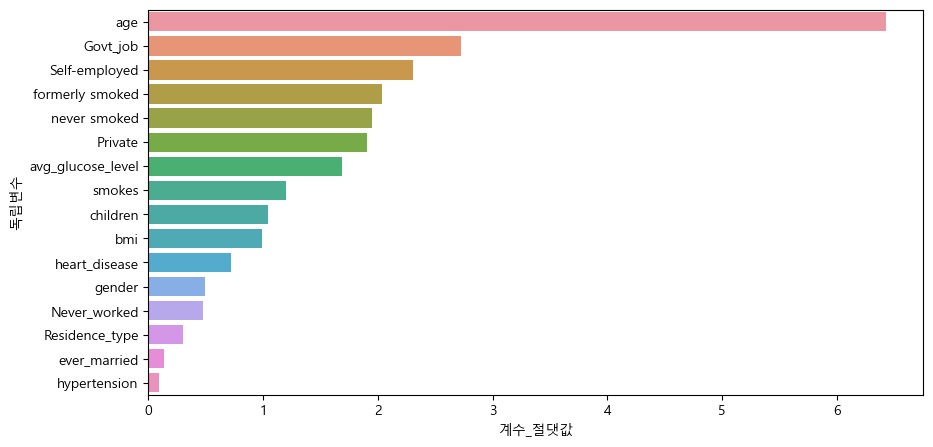

In [104]:
plt.figure(figsize=(10,5))
sns.barplot(data = df,
            x="계수_절댓값", y="독립변수",
            orient="h",
            order=df.sort_values(by="계수_절댓값",ascending=False)["독립변수"])
plt.show()
